In [40]:
%load_ext autoreload
%autoreload 2

import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
from collections import defaultdict 
import ast

sys.path.append(os.path.join(os.getcwd(), '../symlie'))
sys.path.append(os.path.join(os.getcwd(), '..'))
from symlie.misc.viz import plot2d

from symlie.misc.utils_results import pivot, assert_columns_same, get_and_check_Ps, stringify_dict, aggregate_dataset, plot_best, return_table, plot_pivot
from symlie.misc.utils import print_nested_keys
from symlie.misc.wandb import update_results_df, get_inspect_df, get_inspectdev_df
from symlie.model.setup import load_P_pred

sys.path.append(os.path.join(os.getcwd(), '../sympdee/sympde/viz'))
from sympdee.sympde.viz.general_plots import savefig 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
RELOAD_DF = False

store_dir = '../store'
df_path = os.path.join(store_dir, 'combi_show_dev.csv')

if RELOAD_DF:
    df = get_inspectdev_df(tags = ['combi_show_dev'])
    df.to_csv(df_path, index=False)
df = pd.read_csv(df_path)

# df = df[df['n_train'] > 10]
# df = df[df['net'] != 'EMLP']


In [42]:
datasets = {
    'Sine 1D' : '../data/sine1d',
    r'$O(5)$ (Finzi 2021)' : '../data/o5synth',
}

method_dict = {
    'train' : 'ELL',
    'analytic' : 'Analytic ELL',
    'vanilla' : 'Vanilla',
    'emlp' : 'EMLP (Finzi 2021)',
}

title_dict = {
    'bias' : 'With bias',
    'no_bias' : 'Without bias'

}

colors = {'Analytic ELL': 'C0', 'ELL': 'C1', 'Vanilla': 'C2', 'EMLP (Finzi 2021)': 'C3'}

method_dict = defaultdict(lambda: None, method_dict)

    

In [43]:
d_datas = {}

for dataset, data_dir in datasets.items():
    d_data = df[df['data_dir'] == data_dir]
    d_data = d_data.reset_index(drop=True)

    d_data['method'] = d_data['tags'].apply(lambda x: ''.join([method_dict[x_i] for x_i in ast.literal_eval(x) if method_dict[x_i] is not None]))

    columns = ['test_loss_y', 'max_epochs', 'method', 'n_train', 'seed', 'lr', 'bias']
    cols_groupby = ['method', 'n_train']
    loss = 'test_loss_y'
    d_data = d_data[columns]
    d_data = d_data.rename(columns = {'Analytic' : 'Analytic ELL'})

    d_datas[dataset] = {}


    bias_keys = {True : 'bias', False : 'no_bias'}
    for bias_val, bias_key in bias_keys.items():
        d_bias = d_data[d_data['bias'] == bias_val]
        d_datas[dataset][bias_key] = {'d_raw' : d_bias}

        d_datas[dataset][bias_key]['lr'] = {}
        d_lrs = d_bias.groupby('lr')
        for lr, d_lr in d_lrs:
            d_datas[dataset][bias_key]['lr'][lr] = d_lr
        
        
        # ds_plots = {bias_key: {lr: d_lr for lr, d_lr in d_lrs[bias_key]} for bias_key in bias_keys}
        
        
        # d_lrs = {bias_key : ds[bias_key].groupby('lr') for bias_key in bias_keys}
        # ds_plots = {bias_key: {lr: d_lr for lr, d_lr in d_lrs[bias_key]} for bias_key in bias_keys}


print_nested_keys(d_datas)


Sine 1D
  bias
    d_raw
    lr
      0.001
      0.01
      0.1
  no_bias
    d_raw
    lr
      0.001
      0.01
      0.1
$O(5)$ (Finzi 2021)
  bias
    d_raw
    lr
      0.001
      0.01
      0.1
  no_bias
    d_raw
    lr
      0.001
      0.01
      0.1


In [44]:
def get_df_best(d):
    stats_df = d.groupby(['method', 'n_train', 'lr']).agg({'test_loss_y': ['mean', 'std']}).reset_index()
    stats_df.columns = ['method', 'n_train', 'lr', 'mean_loss', 'std_dev']

    idx = stats_df.groupby(['method', 'n_train'])['mean_loss'].idxmin()
    get_df_best = stats_df.loc[idx].reset_index(drop=True)
    return get_df_best

for dataset, ds in d_datas.items():
    for bias_key, d in ds.items():
        d['d_best'] = get_df_best(d['d_raw'])

print_nested_keys(d_datas)

Sine 1D
  bias
    d_raw
    lr
      0.001
      0.01
      0.1
    d_best
  no_bias
    d_raw
    lr
      0.001
      0.01
      0.1
    d_best
$O(5)$ (Finzi 2021)
  bias
    d_raw
    lr
      0.001
      0.01
      0.1
    d_best
  no_bias
    d_raw
    lr
      0.001
      0.01
      0.1
    d_best


In [45]:
d_datas['Sine 1D']['bias']['d_best']

,method,n_train,lr,mean_loss,std_dev
0,Analytic ELL,10,0.010,0.146368,0.032198
1,Analytic ELL,100,0.010,0.076170,0.003862
2,Analytic ELL,1000,0.100,0.075638,0.000919
3,Analytic ELL,10000,0.010,0.073550,0.000525
4,ELL,10,0.001,0.118135,0.009790
5,ELL,100,0.001,0.076710,0.000733
6,ELL,1000,0.010,0.077031,0.001218
7,ELL,10000,0.010,0.073833,0.000179
8,EMLP (Finzi 2021),10,0.001,0.386223,0.007022
9,EMLP (Finzi 2021),100,0.001,0.250127,0.001248


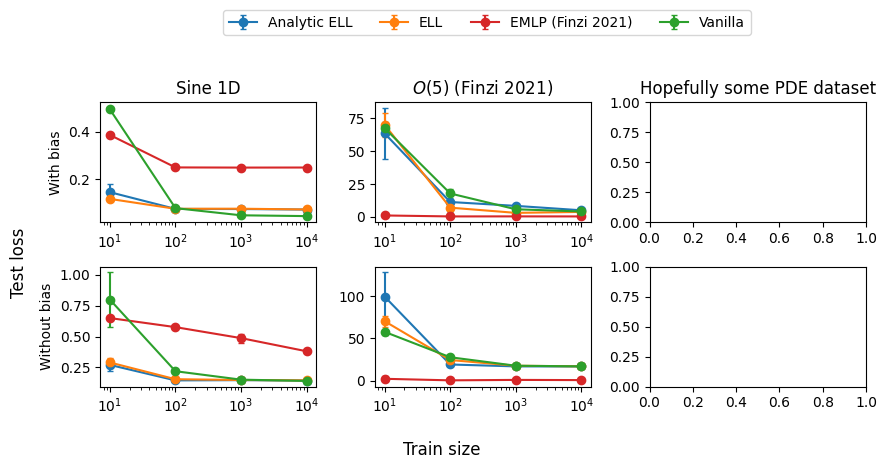

In [46]:
for ylog in [False]:
    n_cols= len(d_datas) + 1
    n_rows = len(d_datas['Sine 1D'])

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2*n_rows), tight_layout = True, sharey = False)

    handles, labels = [], []

    for i, (dataset, ds) in enumerate(d_datas.items()):
        for j, (bias_key, d) in enumerate(ds.items()):
            ax = axs[j, i]
            d_best = d['d_best']
            
            for method, group in d_best.groupby('method'):
                ax.errorbar(group['n_train'], group['mean_loss'], yerr=group['std_dev'], fmt='-o', label=method, color=colors[method], capsize = 2)

            ax.set_xscale('log')
            if ylog:
                ax.set_yscale('log')

            if j == 0:
                ax.set_title(dataset)
            if i == 0:
                ax.set_ylabel(title_dict[bias_key])


            handles_ax, labels_ax = ax.get_legend_handles_labels()
            for handle, label in zip(handles_ax, labels_ax):
                if label not in labels:
                    handles.append(handle)
                    labels.append(label)

    ax = axs[0, 2]
    ax.set_title('Hopefully some PDE dataset')

    fig.supxlabel('Train size')
    fig.supylabel('Test loss')
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.55, 1.15), ncol = len(handles))

savefig(fig, 'implicit_results_best', '5-experiments', bbox_inches = 'tight')

/var/folders/_t/q2qhsxb97lj90dx67tklgrq40000gn/T/ipykernel_78064/3702909308.py:45: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0, 0.6)


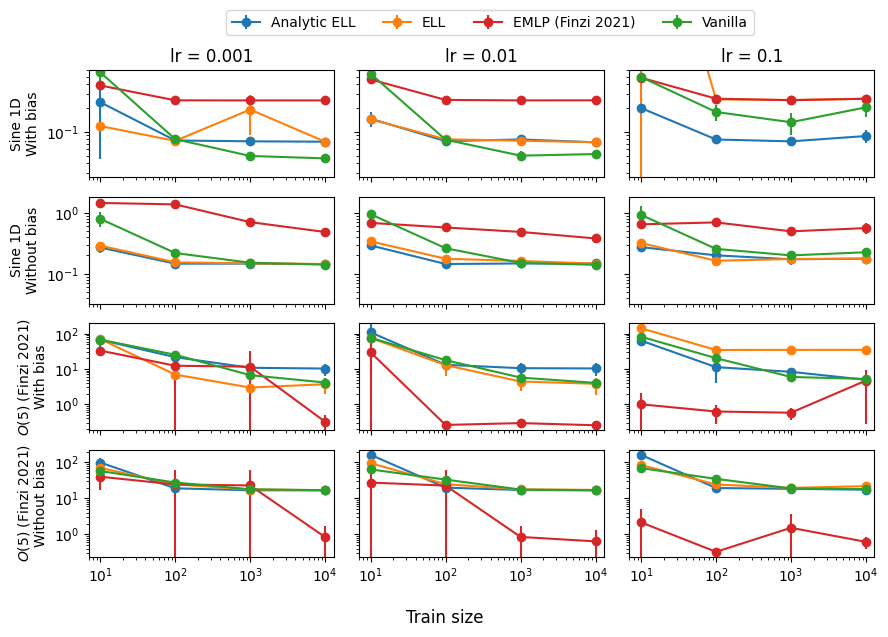

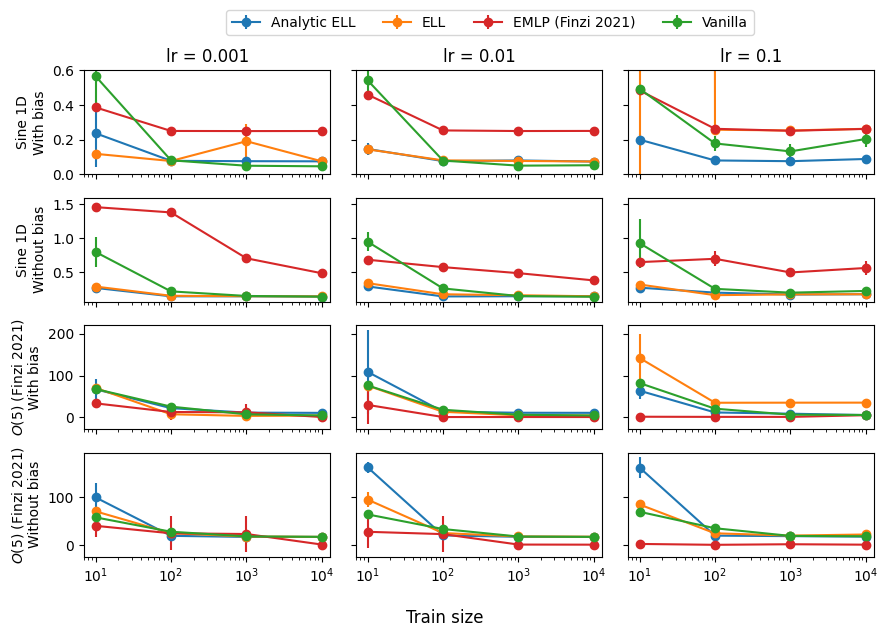

In [47]:
for ylog in [True, False]:
    n_cols = len(d_datas['Sine 1D']['bias']['lr'])
    n_rows = len(d_datas['Sine 1D']) * len(d_datas)

    fig, axs = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 1.5*n_rows), tight_layout = True, sharex = True, sharey = 'row')

    handles, labels = [], []

    row = 0
    for i, (dataset, ds) in enumerate(d_datas.items()):
        for j, (bias_key, d) in enumerate(ds.items()):
            for k, (lr, d_lr) in enumerate(d['lr'].items()):
                ax = axs[row, k]

                grouped = d_lr.groupby(['method', 'n_train'])
                means = grouped['test_loss_y'].mean().reset_index()
                std_devs = grouped['test_loss_y'].std().reset_index()

                # Get the corresponding standard deviations for the group
                for method, group in means.groupby('method'):
                    current_std_dev = std_devs[std_devs['method'] == method]['test_loss_y'].values
                    ax.errorbar(group['n_train'], group['test_loss_y'], yerr=current_std_dev, fmt='-o', label=method, color=colors[method], capsize=0)

                ax.set_xscale('log')
                if ylog: ax.set_yscale('log')

                if row == 0:
                    ax.set_title(f'lr = {lr}')

                if k == 0:
                    ax.set_ylabel(f'{dataset}\n{title_dict[bias_key]}')

                handles_ax, labels_ax = ax.get_legend_handles_labels()
                for handle, label in zip(handles_ax, labels_ax):
                    if label not in labels:
                        handles.append(handle)
                        labels.append(label)

                ax.set_xlim(10**1*0.7, 10**4*1.3)

            row += 1


    ax = axs[0, 2]
    ax.set_ylim(0, 0.6)

    fig.supxlabel('Train size')
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.55, 1.05), ncol = len(handles))
    fig.tight_layout()
    plt.show()

    savefig(fig, 'implicit_results_all' + ('_log' if ylog else ''), '5-experiments', bbox_inches = 'tight')
